In [1]:
import pandas as pd

df = pd.read_csv('silver_prices_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


In [2]:
df.info()
df.describe()
df.isnull().sum()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [3]:
from sklearn.preprocessing import StandardScaler

# Handle missing values
df.ffill(inplace=True)

# Features & target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Scaling (important for Ridge/Lasso)
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Data Ready")

Data Ready


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Models
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

# Train
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
y_lr = lr.predict(X_test)
y_ridge = ridge.predict(X_test)
y_lasso = lasso.predict(X_test)

Linear MSE: 0.07602493072675662
Ridge MSE: 0.11341820419872445
Lasso MSE: 0.24967422895481473

Linear Coefficients: [-4.89174061e+00  7.08499498e+00  6.49645895e+00 -1.14787948e-03]
Ridge Coefficients: [-1.40580837e+00  4.71679809e+00  5.36832989e+00 -1.40056278e-03]
Lasso Coefficients: [0.         3.67185711 4.83471312 0.        ]


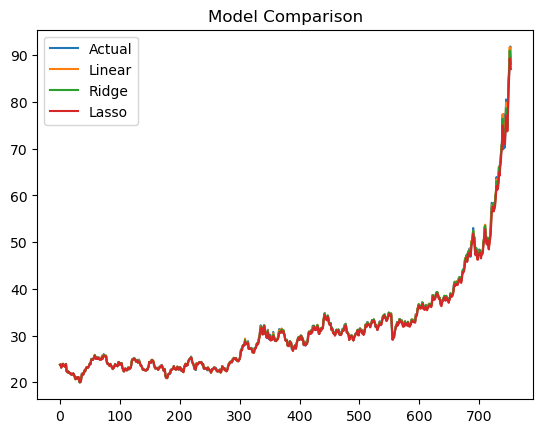

In [5]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# MSE
print("Linear MSE:", mean_squared_error(y_test, y_lr))
print("Ridge MSE:", mean_squared_error(y_test, y_ridge))
print("Lasso MSE:", mean_squared_error(y_test, y_lasso))

# Coefficients
print("\nLinear Coefficients:", lr.coef_)
print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)

# Graph
plt.plot(y_test.values, label="Actual")
plt.plot(y_lr, label="Linear")
plt.plot(y_ridge, label="Ridge")
plt.plot(y_lasso, label="Lasso")
plt.legend()
plt.title("Model Comparison")
plt.show()